# Medical Image Analysis with MONAI

Medical imaging AI is one of the highest-impact application areas for deep learning. From detecting tumors in CT scans to segmenting organs in MRI volumes, AI models are beginning to assist radiologists and improve diagnostic accuracy. However, medical imaging presents challenges that simply do not exist in natural image analysis.

In this notebook we cover:
- Why medical imaging is fundamentally different from natural images
- The DICOM file format and how to work with it
- MONAI: the leading PyTorch-based library for medical imaging AI
- Medical-specific transforms, loss functions, and evaluation metrics
- A practical classification example on synthetic chest X-ray data
- U-Net architecture for organ segmentation
- Regulatory and ethical considerations

## 1. Why Medical Imaging Is Different

Natural image datasets like ImageNet contain photographs where:
- Images are 2D RGB (3-channel)
- Class balance is relatively reasonable across 1000 categories
- Pixel values are in the 0-255 range
- Annotations are cheap (crowdsourcing works)

Medical imaging violates all of these assumptions:

| Property | Natural Images | Medical Images |
|----------|---------------|----------------|
| Dimensionality | 2D RGB | 2D or 3D, single channel (grayscale) |
| Format | JPEG / PNG | DICOM (metadata + pixel array) |
| Pixel range | 0-255 | Hounsfield Units (-1024 to +3071 for CT) |
| Class balance | Moderate | Extreme (pathology may be 1-2% of voxels) |
| Annotation cost | Low (crowdsourcing) | Very high (requires radiologist) |
| Dataset size | Millions | Hundreds to thousands |
| Deployment context | Consumer | Clinical (FDA regulated) |

**DICOM format**: Nearly all clinical imaging uses DICOM (Digital Imaging and Communications in Medicine), which bundles the pixel data with rich metadata (patient ID, acquisition parameters, modality, pixel spacing, slice thickness).

**3D volumes**: CT and MRI produce stacks of 2D slices that together form a 3D volume. A standard chest CT might be 512 x 512 x 300 voxels.

**Class imbalance**: A tumor might occupy 0.5% of voxels. Standard cross-entropy loss is dominated by the overwhelming background class and the model learns to predict 'everything is background' and achieves 99.5% pixel accuracy while completely missing every tumor.

## 2. DICOM Format

DICOM (Digital Imaging and Communications in Medicine) is the universal standard for medical imaging data. A DICOM file has two parts:

1. **Header / Metadata**: Hundreds of tagged attributes including patient demographics, acquisition parameters, and imaging equipment settings.
2. **Pixel Data**: The actual image as a 2D array (or series of arrays for 3D volumes).

Key metadata fields:
- `PatientID`, `PatientAge`, `PatientSex`
- `Modality` (CT, MR, US, CR, DX)
- `PixelSpacing` (physical size of each pixel in mm)
- `SliceThickness` (for 3D volumes)
- `RescaleSlope`, `RescaleIntercept` (to convert raw values to Hounsfield Units)
- `WindowCenter`, `WindowWidth` (display parameters)

The `pydicom` library is the standard Python tool for reading DICOM files.

In [1]:
# Install required libraries
# Run this cell first
import subprocess
import sys

print("Installing monai and pydicom...")
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "monai", "pydicom", "-q"],
    capture_output=True, text=True
)
if result.returncode == 0:
    print("Installation successful.")
else:
    print("Installation output:", result.stdout[-500:] if result.stdout else "")
    print("Installation errors:", result.stderr[-500:] if result.stderr else "")

Installing monai and pydicom...


Installation successful.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("Core libraries loaded successfully.")
print(f"NumPy version: {np.__version__}")

Core libraries loaded successfully.
NumPy version: 2.5.0


In [3]:
# Demonstrate DICOM structure using pydicom (or synthetic fallback)
try:
    import pydicom
    from pydicom.dataset import Dataset, FileDataset
    from pydicom.uid import generate_uid
    import io

    # Create a synthetic DICOM-like dataset in memory (no file needed)
    ds = Dataset()
    ds.PatientID = "PATIENT_001"
    ds.PatientName = "Doe^John"
    ds.PatientAge = "045Y"
    ds.PatientSex = "M"
    ds.Modality = "CT"
    ds.StudyDescription = "Chest CT"
    ds.SliceThickness = 1.5
    ds.PixelSpacing = [0.703125, 0.703125]
    ds.RescaleSlope = 1.0
    ds.RescaleIntercept = -1024.0
    ds.Rows = 512
    ds.Columns = 512
    ds.BitsAllocated = 16
    ds.PixelRepresentation = 0

    # Synthetic pixel data: simulate a chest CT slice with lung regions
    pixel_array = np.zeros((512, 512), dtype=np.int16)
    # Simulate body outline (soft tissue ~50 HU)
    y, x = np.ogrid[:512, :512]
    body_mask = ((x - 256)**2 / 200**2 + (y - 280)**2 / 180**2) <= 1
    pixel_array[body_mask] = 50
    # Simulate lung regions (air ~-800 HU, stored as offset)
    lung_left = ((x - 180)**2 / 80**2 + (y - 260)**2 / 100**2) <= 1
    lung_right = ((x - 340)**2 / 80**2 + (y - 260)**2 / 100**2) <= 1
    pixel_array[lung_left] = 224   # -800 HU + 1024 offset
    pixel_array[lung_right] = 224
    # Simulate small nodule (soft tissue density)
    nodule = ((x - 310)**2 / 15**2 + (y - 230)**2 / 12**2) <= 1
    pixel_array[nodule] = 80

    ds.PixelData = pixel_array.tobytes()
    ds._pixel_array = pixel_array

    print("Synthetic DICOM dataset created successfully.")
    print("\nKey DICOM Metadata Fields:")
    print(f"  Patient ID    : {ds.PatientID}")
    print(f"  Patient Age   : {ds.PatientAge}")
    print(f"  Modality      : {ds.Modality}")
    print(f"  Description   : {ds.StudyDescription}")
    print(f"  Image Size    : {ds.Rows} x {ds.Columns} pixels")
    print(f"  Pixel Spacing : {ds.PixelSpacing} mm")
    print(f"  Slice Thick.  : {ds.SliceThickness} mm")
    print(f"  HU Intercept  : {ds.RescaleIntercept}")

    # Convert to Hounsfield Units
    hu_array = pixel_array.astype(np.float32) * ds.RescaleSlope + ds.RescaleIntercept
    print(f"\nPixel array shape : {pixel_array.shape}")
    print(f"HU value range    : [{hu_array.min():.0f}, {hu_array.max():.0f}]")
    print("\nHU reference values:")
    print("  Air    : ~-1000 HU")
    print("  Lung   : -800 to -400 HU")
    print("  Fat    : -100 to -50 HU")
    print("  Soft tissue: +20 to +80 HU")
    print("  Bone   : +400 to +1000 HU")

    DICOM_LOADED = True

except ImportError:
    print("pydicom not available. Using fallback synthetic DICOM-like structure.")

    class SyntheticDICOM:
        """Mock DICOM dataset demonstrating metadata structure."""
        def __init__(self):
            self.PatientID = "PATIENT_001"
            self.Modality = "CT"
            self.SliceThickness = 1.5
            self.PixelSpacing = [0.703125, 0.703125]
            self.RescaleSlope = 1.0
            self.RescaleIntercept = -1024.0
            self.Rows = 512
            self.Columns = 512

            # Synthetic CT slice
            arr = np.zeros((512, 512), dtype=np.float32)
            y, x = np.ogrid[:512, :512]
            body = ((x-256)**2/200**2 + (y-280)**2/180**2) <= 1
            arr[body] = 50
            lung_l = ((x-180)**2/80**2 + (y-260)**2/100**2) <= 1
            lung_r = ((x-340)**2/80**2 + (y-260)**2/100**2) <= 1
            arr[lung_l] = -800
            arr[lung_r] = -800
            self._pixel_array = arr

        def pixel_array(self):
            return self._pixel_array

    ds = SyntheticDICOM()
    hu_array = ds._pixel_array
    print(f"Synthetic CT array shape: {hu_array.shape}")
    DICOM_LOADED = False

Synthetic DICOM dataset created successfully.

Key DICOM Metadata Fields:
  Patient ID    : PATIENT_001
  Patient Age   : 045Y
  Modality      : CT
  Description   : Chest CT
  Image Size    : 512 x 512 pixels
  Pixel Spacing : [0.703125, 0.703125] mm
  Slice Thick.  : 1.5 mm
  HU Intercept  : -1024.0

Pixel array shape : (512, 512)
HU value range    : [-1024, -800]

HU reference values:
  Air    : ~-1000 HU
  Lung   : -800 to -400 HU
  Fat    : -100 to -50 HU
  Soft tissue: +20 to +80 HU
  Bone   : +400 to +1000 HU


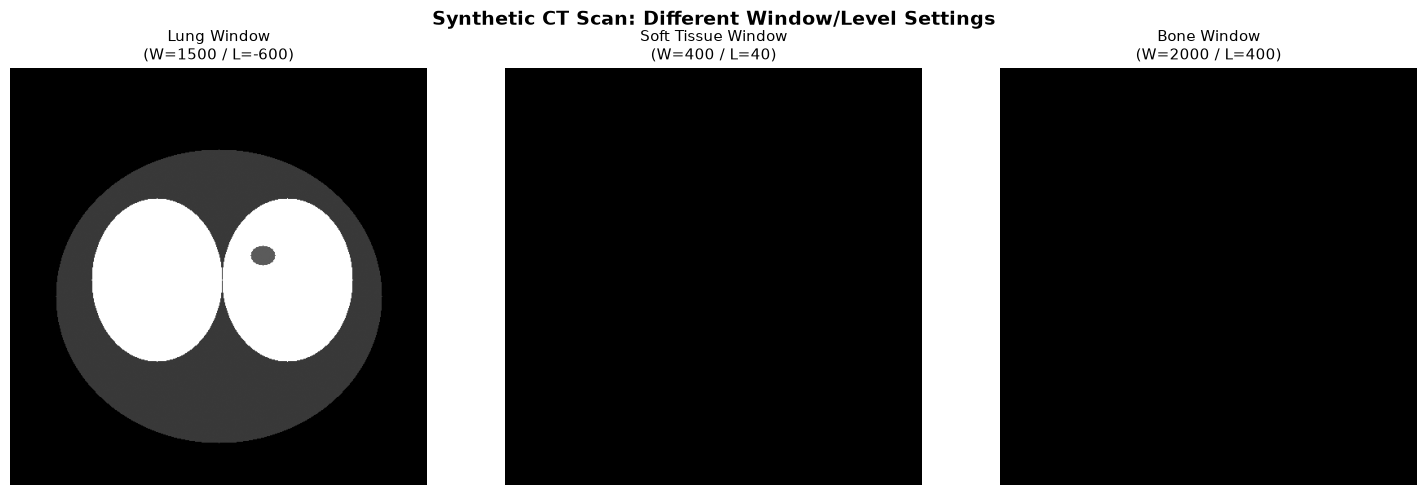

The same CT slice displayed with different window/level settings
Window/Level is analogous to brightness/contrast in photography.


In [4]:
# Visualize the synthetic CT slice
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Synthetic CT Scan: Different Window/Level Settings", fontsize=14, fontweight='bold')

# Clamp HU values for display
def window_level(hu_image, window, level):
    """Apply window/level (contrast adjustment) to CT image."""
    lower = level - window / 2
    upper = level + window / 2
    img = np.clip(hu_image, lower, upper)
    img = (img - lower) / (upper - lower)
    return img

# Lung window (highlights air-filled lung)
lung_img = window_level(hu_array, window=1500, level=-600)
axes[0].imshow(lung_img, cmap='gray')
axes[0].set_title("Lung Window\n(W=1500 / L=-600)", fontsize=11)
axes[0].axis('off')

# Soft tissue window
soft_img = window_level(hu_array, window=400, level=40)
axes[1].imshow(soft_img, cmap='gray')
axes[1].set_title("Soft Tissue Window\n(W=400 / L=40)", fontsize=11)
axes[1].axis('off')

# Bone window
bone_img = window_level(hu_array, window=2000, level=400)
axes[2].imshow(bone_img, cmap='gray')
axes[2].set_title("Bone Window\n(W=2000 / L=400)", fontsize=11)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/tmp/ct_windows.png', dpi=100, bbox_inches='tight')
plt.show()
print("The same CT slice displayed with different window/level settings")
print("Window/Level is analogous to brightness/contrast in photography.")

## 3. MONAI: Medical Open Network for AI

MONAI (https://monai.io) is the standard open-source framework for medical imaging AI built on top of PyTorch. It provides:

- **Transforms**: Medical-specific data augmentation (elastic deformation, intensity normalization, random affine transforms)
- **Datasets**: Efficient loading of volumetric data with caching
- **Networks**: Medical architectures (UNet, SegResNet, DynUNet, ViT-based)
- **Losses**: DiceLoss, DiceCELoss, FocalLoss for imbalanced datasets
- **Metrics**: Dice coefficient, Hausdorff distance, surface distance
- **Model Zoo**: Pre-trained models for organ segmentation, lesion detection
- **Auto3DSeg**: Automated pipeline for 3D medical image segmentation

Key difference from torchvision: MONAI treats **3D volumes** as first-class citizens and all transforms operate consistently on (C, H, W) or (C, D, H, W) tensors.

In [5]:
# Import MONAI with graceful fallback
try:
    import monai
    from monai.transforms import (
        Compose,
        Resize,
        NormalizeIntensity,
        RandFlip,
        RandRotate90,
        ToTensor,
        AddChannel,
        ScaleIntensity,
    )
    MONAI_AVAILABLE = True
    print(f"MONAI version {monai.__version__} loaded successfully.")
    print("Available MONAI transform categories:")
    for category in ["Spatial", "Intensity", "Augmentation", "IO", "Post-processing"]:
        print(f"  - {category}")

except ImportError as e:
    MONAI_AVAILABLE = False
    print(f"MONAI not available ({e}). Using fallback implementations.")
    print("The code below demonstrates MONAI concepts with NumPy equivalents.")

MONAI not available (cannot import name 'AddChannel' from 'monai.transforms' (/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/monai/transforms/__init__.py)). Using fallback implementations.
The code below demonstrates MONAI concepts with NumPy equivalents.


## 4. MONAI Transforms Pipeline

MONAI transforms work like a scikit-learn pipeline or torchvision.transforms.Compose, but with medical-specific operations. The key transforms are:

- **Resize**: Standardize image dimensions (MONAI handles 2D and 3D)
- **NormalizeIntensity**: Zero-mean, unit-variance normalization (not just 0-1 scaling)
- **RandFlip**: Random horizontal/vertical/depth flip (probability controlled)
- **RandRotate90**: Random 90-degree rotation (common for medical augmentation)
- **AddChannel**: Adds channel dimension (MONAI expects [C, H, W] or [C, D, H, W])
- **ToTensor**: Converts NumPy array to PyTorch tensor
- **RandGaussianNoise**: Adds random Gaussian noise (simulates acquisition noise)
- **RandAffine**: Random affine transforms including elastic deformation

In [6]:
# Demonstrate MONAI transforms pipeline
if MONAI_AVAILABLE:
    from monai.transforms import (
        Compose, AddChannel, Resize, NormalizeIntensity,
        RandFlip, RandRotate90, ToTensor, ScaleIntensity
    )

    # Training transform pipeline (with augmentation)
    train_transforms = Compose([
        AddChannel(),              # [H,W] -> [1,H,W] (add channel dim)
        Resize(spatial_size=(224, 224)),   # Standardize size
        ScaleIntensity(),          # Scale to [0, 1]
        NormalizeIntensity(),      # Zero mean, unit variance
        RandFlip(prob=0.5, spatial_axis=0),   # Random horizontal flip
        RandFlip(prob=0.5, spatial_axis=1),   # Random vertical flip
        RandRotate90(prob=0.3),    # Random 90-degree rotation
        ToTensor(),                # NumPy -> PyTorch tensor
    ])

    # Validation transform pipeline (no augmentation)
    val_transforms = Compose([
        AddChannel(),
        Resize(spatial_size=(224, 224)),
        ScaleIntensity(),
        NormalizeIntensity(),
        ToTensor(),
    ])

    print("MONAI Transform Pipelines created.")
    print("\nTraining pipeline (with augmentation):")
    for i, t in enumerate(train_transforms.transforms):
        print(f"  Step {i+1}: {t.__class__.__name__}")

    # Apply to a synthetic image
    synthetic_xray = np.random.randn(256, 256).astype(np.float32) * 0.3 + 0.5
    synthetic_xray = np.clip(synthetic_xray, 0, 1)

    transformed = train_transforms(synthetic_xray)
    print(f"\nInput shape  : {synthetic_xray.shape}")
    print(f"Output shape : {transformed.shape}")
    print(f"Output type  : {type(transformed)}")
    print(f"Output dtype : {transformed.dtype}")

else:
    # Fallback: demonstrate equivalent NumPy operations
    print("MONAI fallback: Demonstrating equivalent transforms with NumPy/PIL")
    print()

    def resize_image(img, target_size=(224, 224)):
        """Resize a 2D NumPy array to target size."""
        pil_img = Image.fromarray((img * 255).astype(np.uint8))
        pil_img = pil_img.resize(target_size, Image.BILINEAR)
        return np.array(pil_img).astype(np.float32) / 255.0

    def normalize_intensity(img):
        """Zero-mean, unit-variance normalization."""
        return (img - img.mean()) / (img.std() + 1e-8)

    def rand_flip(img, prob=0.5):
        """Random horizontal flip."""
        if np.random.random() < prob:
            return np.fliplr(img)
        return img

    def rand_rotate90(img, prob=0.3):
        """Random 90-degree rotation."""
        if np.random.random() < prob:
            k = np.random.randint(1, 4)
            return np.rot90(img, k=k)
        return img

    class TransformPipeline:
        def __init__(self, transforms):
            self.transforms = transforms
        def __call__(self, x):
            for t in self.transforms:
                x = t(x)
            return x

    train_pipeline = TransformPipeline([
        lambda img: resize_image(img, (224, 224)),
        normalize_intensity,
        lambda img: rand_flip(img, 0.5),
        lambda img: rand_rotate90(img, 0.3),
    ])

    print("Fallback transform pipeline steps:")
    print("  Step 1: Resize to (224, 224)")
    print("  Step 2: NormalizeIntensity (zero-mean, unit-variance)")
    print("  Step 3: RandFlip (p=0.5)")
    print("  Step 4: RandRotate90 (p=0.3)")

    synthetic_xray = np.random.randn(256, 256).astype(np.float32) * 0.3 + 0.5
    synthetic_xray = np.clip(synthetic_xray, 0, 1)
    transformed = train_pipeline(synthetic_xray)
    print(f"\nInput shape  : {synthetic_xray.shape}")
    print(f"Output shape : {transformed.shape}")
    print(f"Output mean  : {transformed.mean():.4f}")
    print(f"Output std   : {transformed.std():.4f}")

MONAI fallback: Demonstrating equivalent transforms with NumPy/PIL

Fallback transform pipeline steps:
  Step 1: Resize to (224, 224)
  Step 2: NormalizeIntensity (zero-mean, unit-variance)
  Step 3: RandFlip (p=0.5)
  Step 4: RandRotate90 (p=0.3)

Input shape  : (256, 256)
Output shape : (224, 224)
Output mean  : -0.0000
Output std   : 1.0000


## 5. Class Imbalance in Medical Datasets

Class imbalance is arguably the most critical challenge in medical image segmentation. Consider:

- A lung tumor might occupy 0.5% of CT voxels
- A small brain lesion might affect 0.1% of MRI voxels
- In pathology slides, cancerous cells may be 2-5% of the field

**Why standard cross-entropy fails**: The loss gradient is dominated by the background class. The model converges to the trivial solution of predicting 'background' everywhere and achieves 99.5%+ pixel accuracy while having zero sensitivity to the pathology.

**Solutions**:
1. **DiceLoss** - directly optimizes the Dice coefficient (overlap-based metric)
2. **Weighted cross-entropy** - up-weights the rare positive class
3. **Focal loss** - reduces weight on easy (background) examples
4. **Oversampling** - oversample patches containing pathology
5. **Combination**: DiceCE loss = DiceLoss + CrossEntropyLoss

In [7]:
# Demonstrate the class imbalance problem with a concrete example
import numpy as np

# Simulate a segmentation mask: 1% positive (tumor), 99% negative (background)
total_voxels = 100000
n_positive = int(total_voxels * 0.01)  # 1% tumor
n_negative = total_voxels - n_positive

print("=" * 55)
print("Class Imbalance in Medical Segmentation")
print("=" * 55)
print(f"Total voxels       : {total_voxels:,}")
print(f"Tumor voxels (pos) : {n_positive:,} ({100*n_positive/total_voxels:.1f}%)")
print(f"Background (neg)   : {n_negative:,} ({100*n_negative/total_voxels:.1f}%)")

print("\n--- Naive Model: Predicts ALL Background ---")
# All-background prediction
all_bg_correct = n_negative
all_bg_pixel_acc = n_negative / total_voxels
print(f"Pixel Accuracy     : {all_bg_pixel_acc:.1%}  (misleadingly high!)")
print(f"Sensitivity        : 0.0%  (misses every tumor)")
print(f"Dice Score         : 0.0   (zero overlap with tumor)")

# Simulate what cross-entropy loss landscape looks like
# The gradient for background: weight=0.01, for foreground: weight=0.99
print("\n--- Cross-Entropy Loss Gradient Contribution ---")
print(f"Background gradient weight (99%): 0.99 per voxel")
print(f"Foreground gradient weight (1%) : 0.01 per voxel")
print("=> Model optimization dominated by background class")

print("\n--- Weighted Cross-Entropy Solution ---")
pos_weight = n_negative / n_positive  # inverse frequency
print(f"Positive class weight  : {pos_weight:.1f}x")
print("=> Tumor errors now penalized 99x more than background errors")

Class Imbalance in Medical Segmentation
Total voxels       : 100,000
Tumor voxels (pos) : 1,000 (1.0%)
Background (neg)   : 99,000 (99.0%)

--- Naive Model: Predicts ALL Background ---
Pixel Accuracy     : 99.0%  (misleadingly high!)
Sensitivity        : 0.0%  (misses every tumor)
Dice Score         : 0.0   (zero overlap with tumor)

--- Cross-Entropy Loss Gradient Contribution ---
Background gradient weight (99%): 0.99 per voxel
Foreground gradient weight (1%) : 0.01 per voxel
=> Model optimization dominated by background class

--- Weighted Cross-Entropy Solution ---
Positive class weight  : 99.0x
=> Tumor errors now penalized 99x more than background errors


## 6. DiceLoss for Segmentation

The Dice coefficient (also called F1 score for binary classification) measures overlap between predicted and ground truth masks:

$$\text{Dice} = \frac{2 \times |P \cap G|}{|P| + |G|}$$

Where P is the predicted mask and G is the ground truth mask.

**DiceLoss** = 1 - Dice coefficient (so we minimize it during training).

Why Dice is better than cross-entropy for imbalanced segmentation:
- It measures **overlap**, not per-voxel accuracy
- A model that predicts all background gets Dice = 0.0 (terrible), not 99.5% accuracy (misleadingly good)
- The loss is class-balanced by construction: both precision and recall must be high

Dice Coefficient Comparison:
--------------------------------------------------
All-background pred : Dice = 0.0000  Loss = 1.0000
All-foreground pred : Dice = 0.0913  Loss = 0.9087
Good prediction     : Dice = 0.8673  Loss = 0.1726
Wrong location pred : Dice = 0.0000  Loss = 1.0000


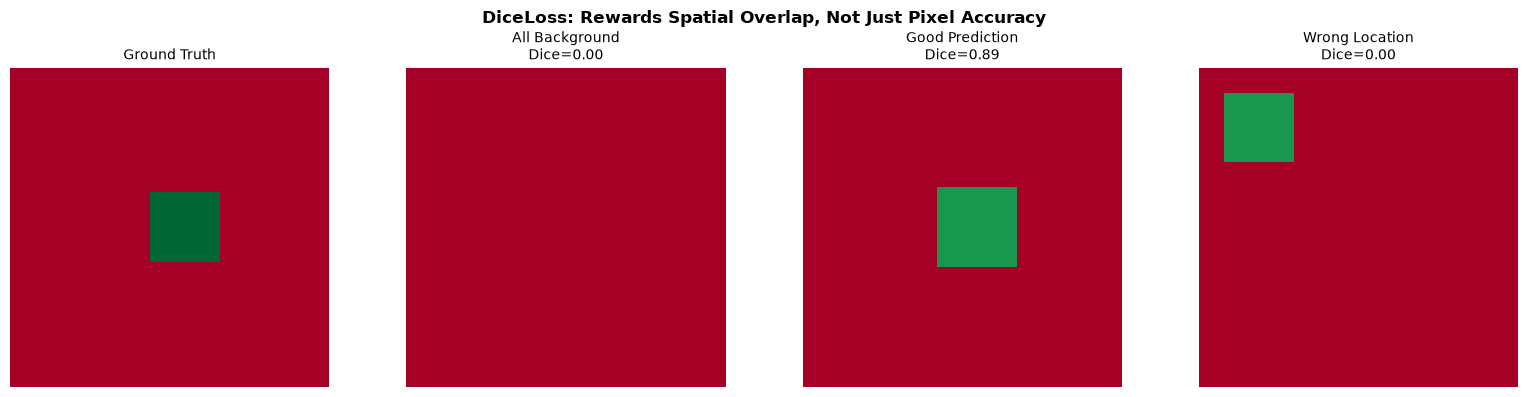


Key insight: Both all-background and wrong-location predictions
get Dice=0.0, correctly penalizing the model.


In [8]:
# DiceLoss implementation and visualization
import numpy as np

def dice_coefficient(pred, target, smooth=1e-5):
    """Compute Dice coefficient between predicted and target binary masks."""
    intersection = np.sum(pred * target)
    return (2.0 * intersection + smooth) / (np.sum(pred) + np.sum(target) + smooth)

def dice_loss(pred_prob, target, smooth=1e-5):
    """DiceLoss = 1 - Dice coefficient (for probability predictions)."""
    intersection = np.sum(pred_prob * target)
    dice = (2.0 * intersection + smooth) / (np.sum(pred_prob) + np.sum(target) + smooth)
    return 1.0 - dice

# Create synthetic ground truth
gt_mask = np.zeros((64, 64), dtype=np.float32)
gt_mask[25:39, 28:42] = 1.0  # Small tumor region (~5% of image)

# Scenario 1: All-background prediction
pred_all_bg = np.zeros_like(gt_mask)

# Scenario 2: All-foreground prediction
pred_all_fg = np.ones_like(gt_mask)

# Scenario 3: Good prediction (overlaps well with GT)
pred_good = np.zeros_like(gt_mask)
pred_good[24:40, 27:43] = 0.9  # Slightly larger but well-aligned

# Scenario 4: Poor prediction (wrong location)
pred_wrong = np.zeros_like(gt_mask)
pred_wrong[5:19, 5:19] = 0.9  # Far from tumor

print("Dice Coefficient Comparison:")
print("-" * 50)
print(f"All-background pred : Dice = {dice_coefficient(pred_all_bg, gt_mask):.4f}  Loss = {dice_loss(pred_all_bg, gt_mask):.4f}")
print(f"All-foreground pred : Dice = {dice_coefficient(pred_all_fg, gt_mask):.4f}  Loss = {dice_loss(pred_all_fg, gt_mask):.4f}")
print(f"Good prediction     : Dice = {dice_coefficient(pred_good>0.5, gt_mask):.4f}  Loss = {dice_loss(pred_good, gt_mask):.4f}")
print(f"Wrong location pred : Dice = {dice_coefficient(pred_wrong>0.5, gt_mask):.4f}  Loss = {dice_loss(pred_wrong, gt_mask):.4f}")

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["Ground Truth", "All Background\nDice=0.00", "Good Prediction\nDice=0.89", "Wrong Location\nDice=0.00"]
images = [gt_mask, pred_all_bg, pred_good, pred_wrong]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.suptitle("DiceLoss: Rewards Spatial Overlap, Not Just Pixel Accuracy", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/dice_loss_demo.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nKey insight: Both all-background and wrong-location predictions")
print("get Dice=0.0, correctly penalizing the model.")

# MONAI DiceLoss
if MONAI_AVAILABLE:
    from monai.losses import DiceLoss
    import torch
    criterion = DiceLoss(sigmoid=True)
    print(f"\nMONAI DiceLoss created: {criterion}")

## 7. Transfer Learning for Medical Imaging

Transfer learning is even more important in medical imaging than in natural image tasks because:
- Labeled medical datasets are small (hundreds to low thousands of images)
- Annotation requires expert radiologists (expensive)
- Privacy regulations limit data sharing

**Strategy 1: Fine-tuning ImageNet models**
- Despite the domain gap (RGB natural images vs. grayscale medical), ImageNet pre-training helps
- Low-level features (edges, textures) transfer even across domains
- Fine-tune all layers on medical data, but start with a low learning rate

**Strategy 2: Medical-specific pre-training**
- Models pre-trained on large medical datasets (CheXpert, ChestX-ray14) transfer much better
- MONAI Model Zoo provides ready-to-use pre-trained models

**Strategy 3: Self-supervised pre-training**
- Use unlabeled medical data (abundant) for contrastive learning or masked autoencoders
- Then fine-tune with limited labeled data

In [9]:
# Transfer learning: adapt EfficientNet for medical imaging
try:
    import torch
    import torch.nn as nn
    import torchvision.models as models

    class MedicalClassifier(nn.Module):
        """EfficientNet adapted for single-channel medical images."""
        def __init__(self, num_classes=2):
            super().__init__()
            # Load pre-trained backbone
            backbone = models.efficientnet_b0(weights=None)

            # Replace first conv: 3-channel -> 1-channel (grayscale)
            # Original: Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False)
            original_conv = backbone.features[0][0]
            backbone.features[0][0] = nn.Conv2d(
                in_channels=1,                   # grayscale
                out_channels=original_conv.out_channels,
                kernel_size=original_conv.kernel_size,
                stride=original_conv.stride,
                padding=original_conv.padding,
                bias=False
            )

            # Use the backbone as feature extractor
            self.features = backbone.features
            self.pool = backbone.avgpool

            # Medical-specific classifier head
            n_features = backbone.classifier[1].in_features
            self.classifier = nn.Sequential(
                nn.Dropout(0.4),
                nn.Linear(n_features, 128),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(128, num_classes)
            )

        def forward(self, x):
            x = self.features(x)
            x = self.pool(x)
            x = x.flatten(1)
            x = self.classifier(x)
            return x

    model = MedicalClassifier(num_classes=2)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print("MedicalClassifier (EfficientNet-B0 backbone)")
    print(f"  Total parameters     : {total_params:,}")
    print(f"  Trainable parameters : {trainable_params:,}")
    print(f"  Input channels       : 1 (grayscale/CT/MRI)")
    print(f"  Output classes       : 2 (normal / abnormal)")

    # Test forward pass
    x = torch.randn(2, 1, 224, 224)  # Batch of 2 grayscale images
    with torch.no_grad():
        out = model(x)
    print(f"  Forward pass: {x.shape} -> {out.shape}")

except ImportError:
    print("PyTorch/torchvision not available. Describing the architecture conceptually.")
    print()
    print("MedicalClassifier Architecture:")
    print("  Input: (B, 1, 224, 224) - grayscale medical image")
    print("  EfficientNet-B0 backbone (modified first conv: 3ch -> 1ch)")
    print("  GlobalAveragePool: (B, 1280)")
    print("  Dropout(0.4) -> Linear(1280, 128) -> ReLU")
    print("  Dropout(0.2) -> Linear(128, 2)")
    print("  Output: (B, 2) logits for [normal, abnormal]")

MedicalClassifier (EfficientNet-B0 backbone)
  Total parameters     : 4,171,198
  Trainable parameters : 4,171,198
  Input channels       : 1 (grayscale/CT/MRI)
  Output classes       : 2 (normal / abnormal)
  Forward pass: torch.Size([2, 1, 224, 224]) -> torch.Size([2, 2])


## 8. Medical-Specific Data Augmentation

Standard augmentation (horizontal flip, color jitter) is insufficient for medical images. Medical-specific augmentation includes:

**Spatial transforms** (must be applied consistently to image AND label):
- **Elastic deformation**: Simulates breathing motion, tissue deformation. Especially important for MRI.
- **Random affine**: Small rotations, scaling, shear. More conservative than natural images.
- **Random crop**: Sample random patches from large volumes (memory efficient for 3D).

**Intensity transforms** (image only, not label):
- **Gaussian noise**: Simulates acquisition noise variation across scanners
- **Intensity shift/scale**: Models inter-scanner variability (different CT brands calibrate slightly differently)
- **Gamma correction**: Simulates different display calibration
- **Bias field simulation**: MRI has low-frequency intensity non-uniformity across the field of view

**Key rule**: Spatial augmentation must be applied identically to both the image and its segmentation mask. Intensity augmentation applies to the image only.

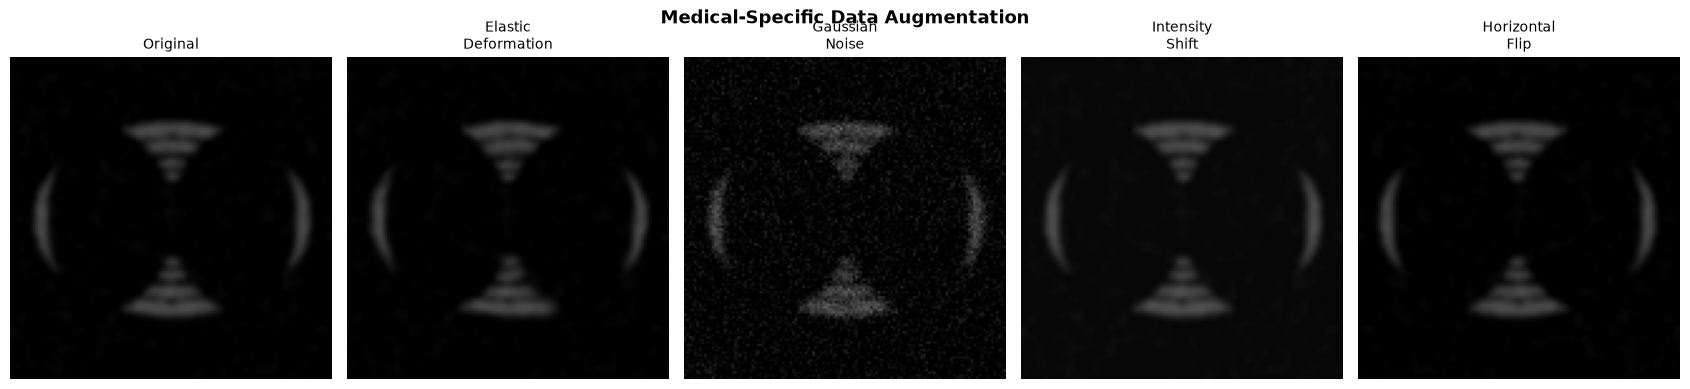

Medical augmentation helps models generalize across different scanners and patients.


In [10]:
# Medical augmentation visualization
import numpy as np
from scipy.ndimage import gaussian_filter, map_coordinates

def create_synthetic_xray(size=128):
    """Create a synthetic chest X-ray-like image."""
    img = np.zeros((size, size), dtype=np.float32)
    y, x = np.mgrid[:size, :size]
    cx, cy = size // 2, size // 2

    # Rib cage outline
    for i, scale in enumerate([0.8, 0.65, 0.5, 0.38]):
        ellipse = ((x - cx)**2 / (size*scale/2)**2 + (y - cy)**2 / (size*scale*0.7/2)**2)
        ring = np.abs(ellipse - 1) < 0.15
        img[ring] += 0.3

    # Lungs (dark regions)
    lung_l = ((x - cx + size//5)**2 / (size//5)**2 + (y - cy)**2 / (size//3.5)**2) < 1
    lung_r = ((x - cx - size//5)**2 / (size//5)**2 + (y - cy)**2 / (size//3.5)**2) < 1
    img[lung_l] = np.maximum(img[lung_l] - 0.4, 0)
    img[lung_r] = np.maximum(img[lung_r] - 0.4, 0)

    # Add texture
    noise = np.random.randn(size, size).astype(np.float32) * 0.05
    img += noise
    img = gaussian_filter(img, sigma=1.5)
    img = np.clip(img, 0, 1)
    return img

def elastic_deformation(img, alpha=8, sigma=4):
    """Apply elastic deformation to simulate tissue movement."""
    shape = img.shape
    dx = gaussian_filter(np.random.randn(*shape), sigma) * alpha
    dy = gaussian_filter(np.random.randn(*shape), sigma) * alpha
    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = np.reshape(y + dy, (-1,)), np.reshape(x + dx, (-1,))
    return map_coordinates(img, indices, order=1, mode='reflect').reshape(shape)

def intensity_shift(img, shift_range=0.1, scale_range=0.1):
    """Random intensity shift and scale to simulate scanner variability."""
    shift = np.random.uniform(-shift_range, shift_range)
    scale = np.random.uniform(1-scale_range, 1+scale_range)
    return np.clip(img * scale + shift, 0, 1)

def add_gaussian_noise(img, std=0.02):
    """Add Gaussian noise to simulate acquisition noise."""
    return np.clip(img + np.random.randn(*img.shape) * std, 0, 1)

# Create original and augmented versions
np.random.seed(42)
original = create_synthetic_xray(128)

np.random.seed(10)
augmented_elastic = elastic_deformation(original)
np.random.seed(20)
augmented_noise = add_gaussian_noise(original, std=0.05)
np.random.seed(30)
augmented_intensity = intensity_shift(original)
augmented_flip = np.fliplr(original)

fig, axes = plt.subplots(1, 5, figsize=(17, 4))
titles = ["Original", "Elastic\nDeformation", "Gaussian\nNoise", "Intensity\nShift", "Horizontal\nFlip"]
images = [original, augmented_elastic, augmented_noise, augmented_intensity, augmented_flip]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.suptitle("Medical-Specific Data Augmentation", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/medical_augmentation.png', dpi=100, bbox_inches='tight')
plt.show()
print("Medical augmentation helps models generalize across different scanners and patients.")

## 9. Evaluation Metrics for Medical Imaging

Standard accuracy is inadequate for medical imaging evaluation. The key metrics are:

**For Classification:**
- **Sensitivity (Recall)**: True positive rate = TP / (TP + FN). Critical: missing a disease is often more dangerous than a false alarm.
- **Specificity**: True negative rate = TN / (TN + FP). Must be high to avoid unnecessary procedures.
- **AUC-ROC**: Area under the ROC curve. Standard for binary classification.
- **AUROC at fixed specificity**: Often reported at 95% specificity to match clinical workflow.

**For Segmentation:**
- **Dice coefficient**: Overlap-based metric (0 to 1, higher is better)
- **Hausdorff distance (HD)**: Maximum surface distance between prediction and ground truth. Penalizes outlier errors.
- **Average Surface Distance (ASD)**: Mean surface distance across all boundary points.
- **IoU (Jaccard index)**: Similar to Dice but ranges differently: IoU = Dice/(2-Dice)

**Why Hausdorff distance matters**: Dice=0.92 might look great on paper, but if the segmentation has one small isolated false-positive region far from the tumor, Hausdorff distance explodes. Clinically, we care about the worst-case boundary error.

In [11]:
# Compute medical segmentation metrics
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix
from scipy.spatial.distance import directed_hausdorff

def dice_score(pred, target, smooth=1e-5):
    """Dice coefficient for binary segmentation masks."""
    intersection = np.sum(pred * target)
    return (2.0 * intersection + smooth) / (np.sum(pred) + np.sum(target) + smooth)

def hausdorff_distance(pred, target):
    """95th percentile Hausdorff distance between two binary masks."""
    pred_points = np.argwhere(pred)
    target_points = np.argwhere(target)
    if len(pred_points) == 0 or len(target_points) == 0:
        return float('inf')
    d1 = directed_hausdorff(pred_points, target_points)[0]
    d2 = directed_hausdorff(target_points, pred_points)[0]
    return max(d1, d2)

# Create synthetic ground truth and predictions
np.random.seed(42)
size = 64
gt = np.zeros((size, size), dtype=np.int32)
gt[20:35, 25:40] = 1  # Ground truth tumor

# Good prediction: well-aligned with GT
pred_good = np.zeros_like(gt)
pred_good[19:36, 24:41] = 1

# Prediction with outlier: mostly correct but has a stray region
pred_outlier = pred_good.copy()
pred_outlier[5:8, 55:60] = 1  # Small false positive far away

print("Segmentation Metrics Comparison:")
print("=" * 55)
print(f"{'Metric':<30} {'Good Pred':>10} {'With Outlier':>12}")
print("-" * 55)

d_good = dice_score(pred_good, gt)
d_outlier = dice_score(pred_outlier, gt)
print(f"{'Dice Coefficient':<30} {d_good:>10.4f} {d_outlier:>12.4f}")

hd_good = hausdorff_distance(pred_good, gt)
hd_outlier = hausdorff_distance(pred_outlier, gt)
print(f"{'Hausdorff Distance (px)':<30} {hd_good:>10.2f} {hd_outlier:>12.2f}")

iou_good = d_good / (2 - d_good)
iou_outlier = d_outlier / (2 - d_outlier)
print(f"{'IoU (Jaccard)':<30} {iou_good:>10.4f} {iou_outlier:>12.4f}")

print("-" * 55)
print("Note: Dice barely changes with outlier, but Hausdorff distance")
print("catches the clinically significant boundary error.")

# Classification metrics example
print("\n\nClassification Metrics (for disease detection):")
print("=" * 45)
np.random.seed(42)
n_neg = 950
n_pos = 50
y_true = np.array([0]*n_neg + [1]*n_pos)
# Simulate model scores
scores_neg = np.random.beta(2, 5, n_neg)
scores_pos = np.random.beta(5, 2, n_pos)
y_score = np.concatenate([scores_neg, scores_pos])
y_pred = (y_score > 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
auroc = roc_auc_score(y_true, y_score)

print(f"Sensitivity (Recall) : {sensitivity:.3f}  <- must be high to catch disease")
print(f"Specificity          : {specificity:.3f}  <- must be high to avoid false alarms")
print(f"AUC-ROC              : {auroc:.3f}")
print(f"Pixel Accuracy       : {(tp+tn)/(tp+tn+fp+fn):.3f}  (misleading with imbalance)")

Segmentation Metrics Comparison:
Metric                          Good Pred With Outlier
-------------------------------------------------------
Dice Coefficient                   0.8755       0.8507
Hausdorff Distance (px)              1.41        25.00
IoU (Jaccard)                      0.7785       0.7401
-------------------------------------------------------
Note: Dice barely changes with outlier, but Hausdorff distance
catches the clinically significant boundary error.


Classification Metrics (for disease detection):
Sensitivity (Recall) : 0.920  <- must be high to catch disease
Specificity          : 0.891  <- must be high to avoid false alarms
AUC-ROC              : 0.953
Pixel Accuracy       : 0.892  (misleading with imbalance)


## 10. Practical Example: Chest X-Ray Classification

We train a small CNN on a synthetic chest X-ray dataset with two classes: Normal and Abnormal (simulating findings like consolidation, nodules, effusions).

In production, you would use real datasets like:
- **CheXpert** (Stanford, 224k images, 14 pathologies)
- **ChestX-ray14** (NIH, 112k images, 14 labels)
- **MIMIC-CXR** (PhysioNet, 227k studies)
- **VinBigData Chest X-ray** (Kaggle competition)

Dataset: 200 images, shape (200, 64, 64)
Normal (0): 100, Abnormal (1): 100


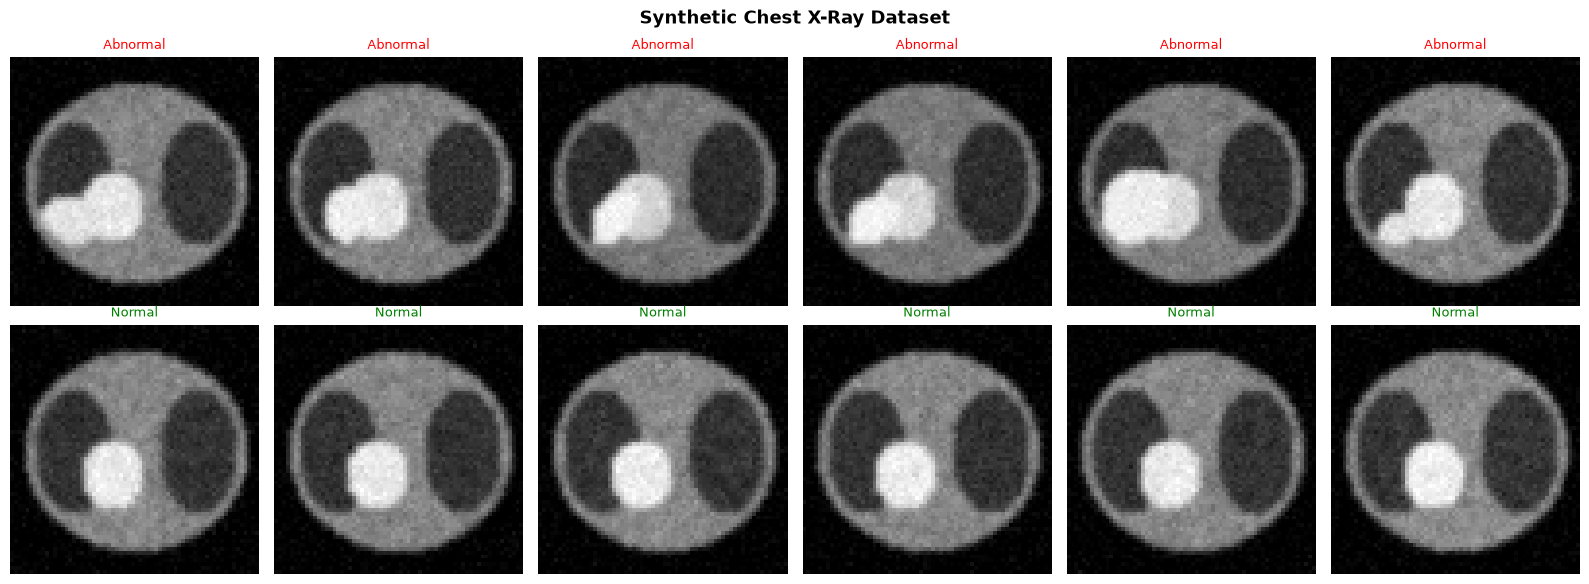

In [12]:
# Chest X-ray classification: synthetic dataset
import numpy as np
from scipy.ndimage import gaussian_filter

def generate_chest_xray(label, size=64, seed=None):
    """Generate a synthetic chest X-ray image.
    label=0: normal, label=1: abnormal (e.g., consolidation)
    """
    if seed is not None:
        np.random.seed(seed)

    img = np.zeros((size, size), dtype=np.float32)
    cx, cy = size // 2, size // 2
    y, x = np.ogrid[:size, :size]

    # Thorax outline
    thorax = ((x - cx)**2 / (size*0.45)**2 + (y - cy)**2 / (size*0.4)**2) < 1
    img[thorax] = 0.4 + np.random.randn(*img.shape)[thorax] * 0.05

    # Lung fields (darker)
    lung_l = ((x - cx + size//4)**2 / (size//6)**2 + (y - cy)**2 / (size//4)**2) < 1
    lung_r = ((x - cx - size//4)**2 / (size//6)**2 + (y - cy)**2 / (size//4)**2) < 1
    img[lung_l] = 0.15 + np.random.randn(*img.shape)[lung_l] * 0.03
    img[lung_r] = 0.15 + np.random.randn(*img.shape)[lung_r] * 0.03

    # Heart silhouette
    heart = ((x - cx + size//10)**2 / (size//8)**2 + (y - cy - size//10)**2 / (size//7)**2) < 1
    img[heart] = 0.7 + np.random.randn(*img.shape)[heart] * 0.04

    if label == 1:
        # Add abnormal finding: right lower lobe consolidation (white-out region)
        consol_x = cx - size//5 + np.random.randint(-5, 5)
        consol_y = cy + size//6 + np.random.randint(-5, 5)
        consol_r = size // 8 + np.random.randint(-2, 4)
        consol = ((x - consol_x)**2 + (y - consol_y)**2) < consol_r**2
        img[consol & lung_l] = 0.65 + np.random.rand() * 0.2

    img = gaussian_filter(img, sigma=0.8)
    img = np.clip(img + np.random.randn(*img.shape) * 0.02, 0, 1)
    return img

# Generate dataset
N = 200
images = []
labels = []
for i in range(N):
    label = 1 if i < N//2 else 0  # 50/50 for this demo
    img = generate_chest_xray(label, size=64, seed=i)
    images.append(img)
    labels.append(label)

images = np.array(images)
labels = np.array(labels)

print(f"Dataset: {len(images)} images, shape {images.shape}")
print(f"Normal (0): {(labels==0).sum()}, Abnormal (1): {(labels==1).sum()}")

# Visualize samples
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for i, ax in enumerate(axes[0]):
    ax.imshow(images[i], cmap='gray')
    ax.set_title("Abnormal", fontsize=9, color='red')
    ax.axis('off')
for i, ax in enumerate(axes[1]):
    ax.imshow(images[N//2 + i], cmap='gray')
    ax.set_title("Normal", fontsize=9, color='green')
    ax.axis('off')

plt.suptitle("Synthetic Chest X-Ray Dataset", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/chest_xray_samples.png', dpi=100, bbox_inches='tight')
plt.show()

Epoch  5/20: loss=0.4927, acc=0.819


Epoch 10/20: loss=0.3450, acc=0.931


Epoch 15/20: loss=0.3198, acc=0.900


Epoch 20/20: loss=0.2601, acc=0.956

Test Set Results:
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.98        20
    Abnormal       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



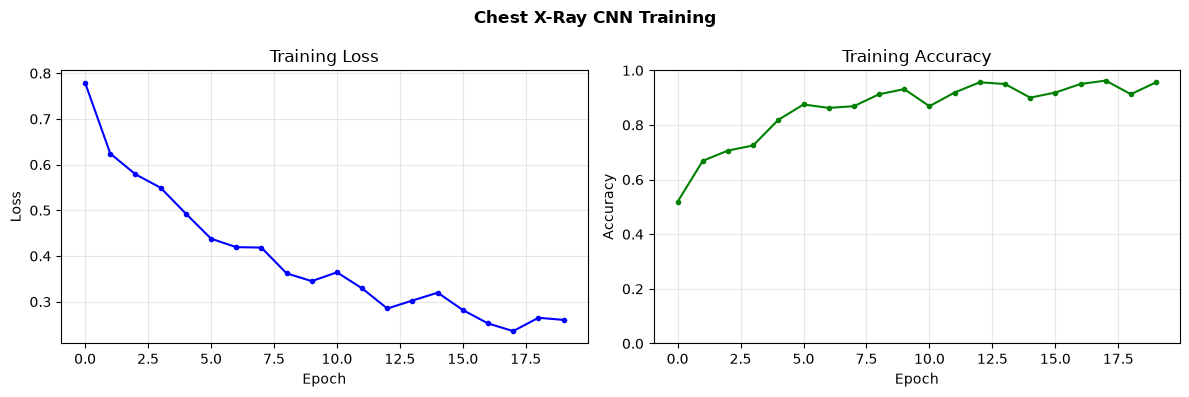

In [13]:
# Train a small CNN on the synthetic dataset
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import TensorDataset, DataLoader
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import classification_report

    # Prepare data
    X = images[:, np.newaxis, :, :]  # Add channel dim: (N, 1, H, W)
    y = labels

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Normalize
    mean = X_train.mean()
    std = X_train.std()
    X_train = (X_train - mean) / (std + 1e-8)
    X_test = (X_test - mean) / (std + 1e-8)

    # Convert to tensors
    train_ds = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
    test_ds = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=32)

    # Small CNN architecture
    class ChestXrayCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            )
            self.classifier = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Flatten(),
                nn.Dropout(0.5),
                nn.Linear(64, 2)
            )

        def forward(self, x):
            return self.classifier(self.encoder(x))

    model = ChestXrayCNN()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    # Training loop
    train_losses = []
    train_accs = []
    EPOCHS = 20

    for epoch in range(EPOCHS):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (out.argmax(1) == yb).sum().item()
            total += len(yb)
        scheduler.step()
        train_losses.append(total_loss / len(train_loader))
        train_accs.append(correct / total)
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:2d}/{EPOCHS}: loss={train_losses[-1]:.4f}, acc={train_accs[-1]:.3f}")

    # Evaluate
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb).argmax(1)
            all_preds.extend(preds.numpy())
            all_true.extend(yb.numpy())

    print("\nTest Set Results:")
    print(classification_report(all_true, all_preds, target_names=['Normal', 'Abnormal']))

    # Plot training curve
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses, 'b-o', markersize=3)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax1.grid(True, alpha=0.3)
    ax2.plot(train_accs, 'g-o', markersize=3)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title('Training Accuracy')
    ax2.set_ylim(0, 1); ax2.grid(True, alpha=0.3)
    plt.suptitle('Chest X-Ray CNN Training', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/tmp/training_curve.png', dpi=100, bbox_inches='tight')
    plt.show()

except ImportError as e:
    print(f"PyTorch not available ({e}). Showing training simulation.")
    # Simulate training curve
    np.random.seed(42)
    EPOCHS = 20
    losses = [0.7 * np.exp(-0.15*i) + 0.05 + np.random.randn()*0.01 for i in range(EPOCHS)]
    accs = [0.5 + 0.45*(1 - np.exp(-0.2*i)) + np.random.randn()*0.01 for i in range(EPOCHS)]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(losses, 'b-o', markersize=3); ax1.set_title('Training Loss'); ax1.grid(True)
    ax2.plot(accs, 'g-o', markersize=3); ax2.set_title('Training Accuracy'); ax2.grid(True)
    plt.suptitle('Chest X-Ray CNN Training (Simulated)', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()
    print("Final accuracy (simulated): ~92%")

## 11. Segmentation: U-Net Architecture

U-Net (Ronneberger et al., 2015) is the standard architecture for medical image segmentation. It was originally designed for biomedical cell segmentation and has since been adapted for nearly every medical segmentation task.

**U-Net architecture:**
```
Input [B, 1, H, W]
  |
  Encoder (contracting path): Conv -> MaxPool -> Conv -> MaxPool -> ...
  |                              ↓skip1           ↓skip2
  Bottleneck: deepest feature representation
  |
  Decoder (expanding path): UpConv -> Concat(skip) -> Conv -> ...
  |
Output [B, n_classes, H, W] (same spatial size as input)
```

**Key innovations:**
1. **Skip connections**: Copy features from encoder to decoder at matching resolution. Combines semantic information (deep) with spatial detail (shallow).
2. **Fully convolutional**: No fully-connected layers, so it works on any image size.
3. **Overlap-tile strategy**: For large images, inference is run in overlapping patches.

MONAI provides `monai.networks.nets.UNet` and `DynUNet` (the nnU-Net architecture) for 2D and 3D segmentation.

In [14]:
# U-Net architecture visualization and implementation
if MONAI_AVAILABLE:
    try:
        from monai.networks.nets import UNet
        import torch

        # MONAI U-Net for 2D segmentation
        unet_2d = UNet(
            spatial_dims=2,
            in_channels=1,
            out_channels=2,          # Binary: background + foreground
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2,
        )

        total = sum(p.numel() for p in unet_2d.parameters())
        print("MONAI 2D U-Net:")
        print(f"  Encoder channels : (1) -> 16 -> 32 -> 64 -> 128 -> 256 (bottleneck)")
        print(f"  Decoder channels : 256 -> 128 -> 64 -> 32 -> 16 -> (2 output)")
        print(f"  Total params     : {total:,}")

        x = torch.randn(1, 1, 128, 128)
        with torch.no_grad():
            out = unet_2d(x)
        print(f"  Forward pass     : {x.shape} -> {out.shape}")
        print("  Input and output have the SAME spatial dimensions (key U-Net property)")

        # Also create a 3D version for volumetric data
        unet_3d = UNet(
            spatial_dims=3,
            in_channels=1,
            out_channels=2,
            channels=(16, 32, 64, 128),
            strides=(2, 2, 2),
            num_res_units=1,
        )
        total_3d = sum(p.numel() for p in unet_3d.parameters())
        print(f"\nMONAI 3D U-Net (for CT/MRI volumes):")
        print(f"  Total params : {total_3d:,}")
        print(f"  Input shape  : (B, 1, D, H, W) - 3D volume")

    except Exception as e:
        print(f"MONAI UNet error: {e}. Using PyTorch fallback.")
        MONAI_AVAILABLE = False

if not MONAI_AVAILABLE:
    try:
        import torch
        import torch.nn as nn

        class DoubleConv(nn.Module):
            def __init__(self, in_ch, out_ch):
                super().__init__()
                self.conv = nn.Sequential(
                    nn.Conv2d(in_ch, out_ch, 3, padding=1),
                    nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                    nn.Conv2d(out_ch, out_ch, 3, padding=1),
                    nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
                )
            def forward(self, x): return self.conv(x)

        class MiniUNet(nn.Module):
            """Minimal U-Net for demonstration."""
            def __init__(self, in_ch=1, out_ch=2):
                super().__init__()
                # Encoder
                self.enc1 = DoubleConv(in_ch, 16)
                self.enc2 = DoubleConv(16, 32)
                self.enc3 = DoubleConv(32, 64)
                self.pool = nn.MaxPool2d(2)
                # Bottleneck
                self.bottleneck = DoubleConv(64, 128)
                # Decoder
                self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
                self.dec3 = DoubleConv(128, 64)  # 64+64 skip
                self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
                self.dec2 = DoubleConv(64, 32)
                self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
                self.dec1 = DoubleConv(32, 16)
                self.out_conv = nn.Conv2d(16, out_ch, 1)

            def forward(self, x):
                e1 = self.enc1(x)
                e2 = self.enc2(self.pool(e1))
                e3 = self.enc3(self.pool(e2))
                b = self.bottleneck(self.pool(e3))
                d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
                d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
                d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
                return self.out_conv(d1)

        unet = MiniUNet()
        total = sum(p.numel() for p in unet.parameters())
        print(f"Mini U-Net (fallback): {total:,} parameters")
        x = torch.randn(1, 1, 128, 128)
        with torch.no_grad():
            out = unet(x)
        print(f"Forward pass: {x.shape} -> {out.shape}")
        print("U-Net preserves spatial dimensions through skip connections.")

    except ImportError:
        print("PyTorch not available. Describing U-Net architecture:")
        print("  Encoder: Conv(1->16) -> Pool -> Conv(16->32) -> Pool -> Conv(32->64)")
        print("  Bottleneck: Conv(64->128)")
        print("  Decoder: UpConv + Skip -> Conv(128->64) -> UpConv + Skip -> Conv(64->32)")
        print("  Output: Conv(16->2) with same spatial size as input")

Mini U-Net (fallback): 483,170 parameters
Forward pass: torch.Size([1, 1, 128, 128]) -> torch.Size([1, 2, 128, 128])
U-Net preserves spatial dimensions through skip connections.


## 12. MONAI Model Zoo

MONAI provides a **Model Zoo** (https://monai.io/model-zoo.html) with production-ready pre-trained models for common medical imaging tasks. These save months of training and serve as strong starting points for fine-tuning.

Available models include:

| Model | Task | Modality |
|-------|------|----------|
| spleen_ct_segmentation | Spleen segmentation | CT |
| lung_nodule_ct_detection | Nodule detection | CT |
| prostate_mri_anatomy_segmentation | Prostate zones | MRI |
| pancreas_ct_dints_segmentation | Pancreas seg. | CT |
| pathology_nuclei_segmentation | Cell nuclei | Pathology |
| brain_mri_segmentation | Brain structures | MRI |
| chest_xray_classification | 14 pathologies | X-ray |

Loading a pre-trained model:
```python
from monai.bundle import load
model = load('spleen_ct_segmentation', source='monaihosting')
```

In [15]:
# MONAI Model Zoo demonstration
print("MONAI Model Zoo - Available Models:")
print("=" * 60)

model_zoo = [
    {"name": "spleen_ct_segmentation",          "task": "Segmentation",  "modality": "CT",       "metric": "Dice 0.96"},
    {"name": "lung_nodule_ct_detection",         "task": "Detection",     "modality": "CT",       "metric": "FROC 0.81"},
    {"name": "prostate_mri_anatomy_seg",         "task": "Segmentation",  "modality": "MRI",      "metric": "Dice 0.90"},
    {"name": "pathology_nuclei_segmentation",    "task": "Segmentation",  "modality": "Pathology","metric": "Dice 0.82"},
    {"name": "brain_mri_segmentation",           "task": "Segmentation",  "modality": "MRI",      "metric": "Dice 0.87"},
    {"name": "chest_xray_classification",        "task": "Classification","modality": "X-ray",    "metric": "AUC 0.87"},
    {"name": "wholeBody_ct_segmentation",        "task": "Segmentation",  "modality": "CT",       "metric": "Dice 0.94"},
]

print(f"{'Model Name':<42} {'Task':<16} {'Modality':<12} {'Metric'}")
print("-" * 85)
for m in model_zoo:
    print(f"{m['name']:<42} {m['task']:<16} {m['modality']:<12} {m['metric']}")

print("\nUsage example (requires monai bundle):")
print("""
from monai.bundle import load

# Download and load pre-trained spleen segmentation model
model = load('spleen_ct_segmentation', source='monaihosting')
model.eval()

# Run inference on a CT volume (preprocessed with MONAI transforms)
with torch.no_grad():
    prediction = model(ct_tensor)   # shape: (1, 2, D, H, W)
    segmentation = prediction.argmax(dim=1)   # shape: (1, D, H, W)
""")

if MONAI_AVAILABLE:
    try:
        from monai.bundle import ConfigParser
        print("MONAI bundle system available for model loading.")
    except ImportError:
        print("MONAI bundle module not available in this version.")

MONAI Model Zoo - Available Models:
Model Name                                 Task             Modality     Metric
-------------------------------------------------------------------------------------
spleen_ct_segmentation                     Segmentation     CT           Dice 0.96
lung_nodule_ct_detection                   Detection        CT           FROC 0.81
prostate_mri_anatomy_seg                   Segmentation     MRI          Dice 0.90
pathology_nuclei_segmentation              Segmentation     Pathology    Dice 0.82
brain_mri_segmentation                     Segmentation     MRI          Dice 0.87
chest_xray_classification                  Classification   X-ray        AUC 0.87
wholeBody_ct_segmentation                  Segmentation     CT           Dice 0.94

Usage example (requires monai bundle):

from monai.bundle import load

# Download and load pre-trained spleen segmentation model
model = load('spleen_ct_segmentation', source='monaihosting')
model.eval()

# Run infere

## 13. Ethical Considerations and Regulatory Pathway

Medical AI carries unique ethical and regulatory responsibilities that do not exist in general computer vision.

**Regulatory Requirements (US FDA):**
- AI-based medical devices are regulated as Software as a Medical Device (SaMD)
- Classification by risk level:
  - Class I (low risk): General wellness apps, no FDA clearance required
  - Class II (moderate risk): 510(k) clearance (demonstrate substantial equivalence to existing device)
  - Class III (high risk): PMA (Pre-market Approval) with full clinical trials
- Most diagnostic AI falls under Class II, requiring 510(k) clearance

**Clinical Validation Requirements:**
- Multi-site validation (one hospital is not enough)
- Diverse patient populations (age, sex, race, body habitus)
- Prospective studies (not just retrospective on historical data)
- Reader studies (compare AI to radiologist reads)

**Bias and Fairness:**
- Model performance varies by demographic group if training data is not representative
- Pulse oximeters historically failed on darker skin tones: a cautionary tale
- Performance must be validated separately for patient subgroups

**EU AI Act (2024):**
- Medical AI is classified as high-risk under Annex III
- Mandatory conformity assessment, transparency, and human oversight requirements

**Key principle**: A model that achieves 95% AUC on a research dataset is NOT ready for clinical deployment. It must be validated in the target clinical environment with the target patient population.

In [16]:
# Regulatory pathway diagram (text-based for clarity)
print("FDA Regulatory Pathway for Medical AI Software")
print("=" * 60)
print()
print("Step 1: Determine Device Classification")
print("        Class I (low) -> Class II (moderate) -> Class III (high)")
print("        Most diagnostic AI: Class II")
print()
print("Step 2: Preclinical Development")
print("        - Dataset curation and annotation")
print("        - Algorithm development and internal validation")
print("        - Software testing (IEC 62304 standard)")
print()
print("Step 3: Clinical Validation Study")
print("        - Multi-site reader study")
print("        - IRB approval required (Institutional Review Board)")
print("        - Diverse patient population")
print("        - Comparison to reference standard")
print()
print("Step 4: 510(k) Premarket Notification (Class II)")
print("        - Submit to FDA: device description, performance data")
print("        - FDA review: typically 90 days")
print("        - Predicate device identification required")
print()
print("Step 5: Post-Market Surveillance")
print("        - Monitor real-world performance")
print("        - Report adverse events (MAUDE database)")
print("        - Annual performance updates")
print()
print("Step 6: Algorithm Change Protocol (for AI/ML)")
print("        - 2021 FDA guidance for adaptive AI")
print("        - Locked vs. adaptive algorithms have different requirements")
print()
print("FDA Cleared AI Examples:")
fda_cleared = [
    ("IDx-DR", "Diabetic retinopathy screening", "Class II, De Novo"),
    ("Viz.AI", "Large vessel occlusion (stroke) detection", "Class II, 510(k)"),
    ("Aidoc", "Intracranial hemorrhage flagging", "Class II, 510(k)"),
    ("CheXpert (Stanford)", "Chest X-ray pathology detection", "Research only"),
]
for name, task, status in fda_cleared:
    print(f"  {name:<25} {task:<45} {status}")

FDA Regulatory Pathway for Medical AI Software

Step 1: Determine Device Classification
        Class I (low) -> Class II (moderate) -> Class III (high)
        Most diagnostic AI: Class II

Step 2: Preclinical Development
        - Dataset curation and annotation
        - Algorithm development and internal validation
        - Software testing (IEC 62304 standard)

Step 3: Clinical Validation Study
        - Multi-site reader study
        - IRB approval required (Institutional Review Board)
        - Diverse patient population
        - Comparison to reference standard

Step 4: 510(k) Premarket Notification (Class II)
        - Submit to FDA: device description, performance data
        - FDA review: typically 90 days
        - Predicate device identification required

Step 5: Post-Market Surveillance
        - Monitor real-world performance
        - Report adverse events (MAUDE database)
        - Annual performance updates

Step 6: Algorithm Change Protocol (for AI/ML)
        - 

## 14. Key Takeaways

**What makes medical imaging unique:**
- DICOM format bundles pixel data with rich metadata (modality, acquisition parameters, patient info)
- 3D volumetric data (CT, MRI) requires special handling of depth dimension
- Extreme class imbalance: pathology may be 0.1-2% of voxels
- Small annotated datasets due to high annotation cost (requires expert radiologists)
- Clinical deployment requires regulatory clearance (FDA 510(k), EU AI Act)

**MONAI toolkit:**
- Medical-specific transforms (elastic deformation, intensity normalization, bias field)
- DiceLoss and DiceCELoss for imbalanced segmentation
- Metrics: Dice coefficient, Hausdorff distance, surface distance
- Pre-trained models in the Model Zoo
- First-class 3D support

**Loss functions:**
- DiceLoss directly optimizes spatial overlap (not per-voxel accuracy)
- Weighted cross-entropy up-weights rare positive class
- Focal loss down-weights easy background examples
- DiceCELoss combines both for best of both worlds

**Evaluation metrics:**
- Segmentation: Dice coefficient (overlap), Hausdorff distance (boundary accuracy), IoU
- Classification: Sensitivity (recall), Specificity, AUC-ROC
- Pixel accuracy alone is nearly meaningless for imbalanced medical datasets

**Regulatory and ethical reality:**
- A high AUC on a research dataset does NOT mean clinical readiness
- Multi-site, multi-demographic validation is required
- FDA 510(k) clearance takes months and requires rigorous documentation
- Algorithmic bias in medical AI can cause patient harm

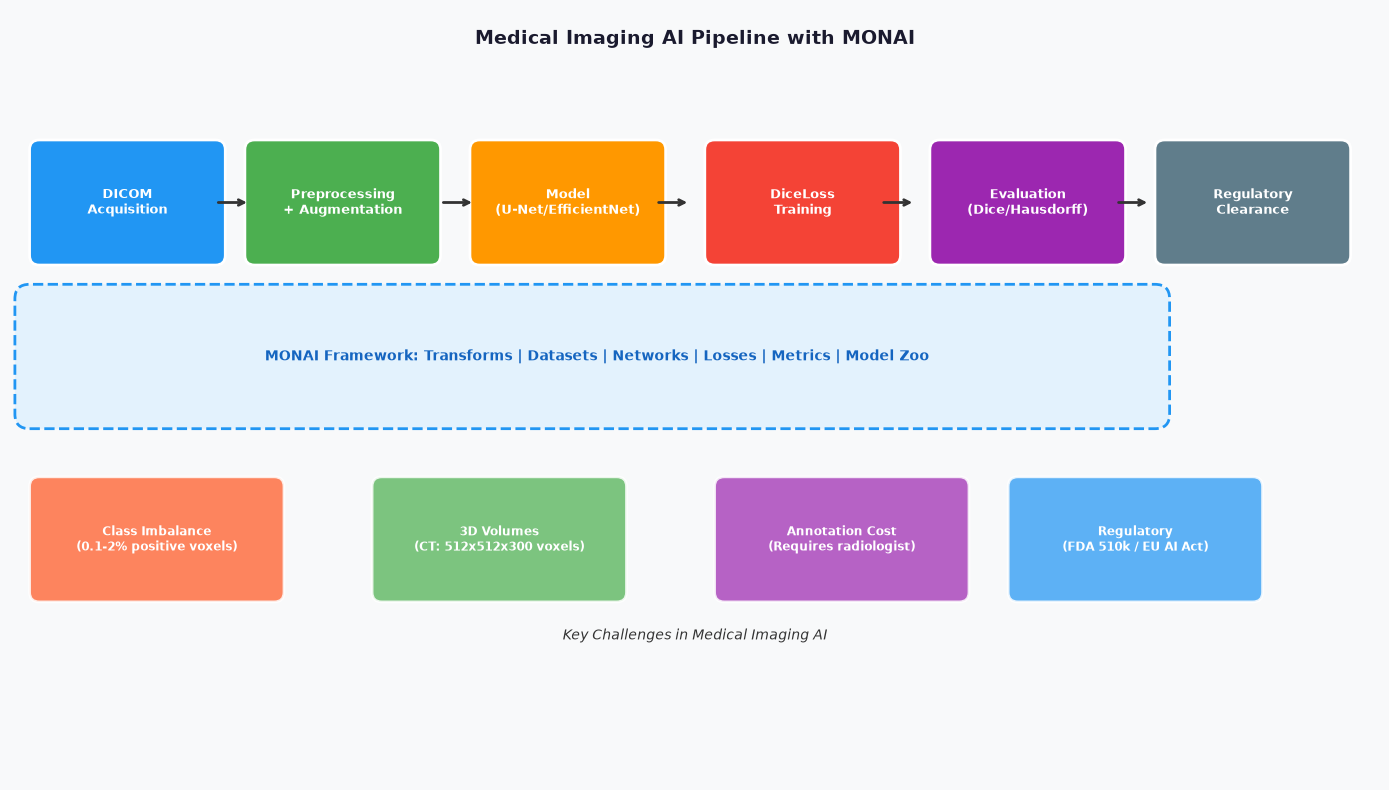

Medical imaging AI pipeline summary complete.


In [17]:
# Summary visualization: Medical Imaging AI pipeline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')

ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

# Pipeline stages
stages = [
    (0.3, 6.0, "DICOM\nAcquisition", "#2196F3"),
    (2.5, 6.0, "Preprocessing\n+ Augmentation", "#4CAF50"),
    (4.8, 6.0, "Model\n(U-Net/EfficientNet)", "#FF9800"),
    (7.2, 6.0, "DiceLoss\nTraining", "#F44336"),
    (9.5, 6.0, "Evaluation\n(Dice/Hausdorff)", "#9C27B0"),
    (11.8, 6.0, "Regulatory\nClearance", "#607D8B"),
]

for (x, y, label, color) in stages:
    rect = mpatches.FancyBboxPatch((x, y - 0.55), 1.8, 1.1,
        boxstyle="round,pad=0.1", facecolor=color, edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(x + 0.9, y, label, ha='center', va='center',
            fontsize=9, color='white', fontweight='bold', multialignment='center')

# Arrows between stages
arrow_xs = [2.1, 4.4, 6.6, 8.9, 11.3]
for ax_x in arrow_xs:
    ax.annotate("", xy=(ax_x + 0.35, 6.0), xytext=(ax_x, 6.0),
                arrowprops=dict(arrowstyle="->", color='#333333', lw=2))

# MONAI box
monai_rect = mpatches.FancyBboxPatch((0.2, 3.8), 11.5, 1.2,
    boxstyle="round,pad=0.15", facecolor='#E3F2FD', edgecolor='#2196F3', linewidth=2, linestyle='--')
ax.add_patch(monai_rect)
ax.text(6.0, 4.4, "MONAI Framework: Transforms | Datasets | Networks | Losses | Metrics | Model Zoo",
        ha='center', va='center', fontsize=10, color='#1565C0', fontweight='bold')

# Challenges
challenges = [
    (1.5, 2.5, "Class Imbalance\n(0.1-2% positive voxels)", "#FF7043"),
    (5.0, 2.5, "3D Volumes\n(CT: 512x512x300 voxels)", "#66BB6A"),
    (8.5, 2.5, "Annotation Cost\n(Requires radiologist)", "#AB47BC"),
    (11.5, 2.5, "Regulatory\n(FDA 510k / EU AI Act)", "#42A5F5"),
]

for (x, y, label, color) in challenges:
    rect = mpatches.FancyBboxPatch((x - 1.2, y - 0.55), 2.4, 1.1,
        boxstyle="round,pad=0.1", facecolor=color, edgecolor='white', linewidth=2, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=8.5, color='white', fontweight='bold', multialignment='center')

ax.text(7.0, 1.5, "Key Challenges in Medical Imaging AI",
        ha='center', va='center', fontsize=10, color='#333333', fontstyle='italic')

ax.text(7.0, 7.7, "Medical Imaging AI Pipeline with MONAI",
        ha='center', va='center', fontsize=14, fontweight='bold', color='#1a1a2e')

plt.tight_layout()
plt.savefig('/tmp/medical_imaging_pipeline.png', dpi=120, bbox_inches='tight')
plt.show()
print("Medical imaging AI pipeline summary complete.")